## Helper Functions

In [2]:
import pandas as pd
from pathlib import Path
file_name = 'Front_EE-1_1_3000x_rings_coords.csv'
path_to_main_folder = Path('/Users/rishabhkumar/spiral-chirals')
# csv_file = Path('/Users/rishabhkumar/spiral-chirals/vf_exports/Front_EE-1_1_3000x_rings_coords.csv')
csv_file = path_to_main_folder / 'vf_exports' / file_name
with open(csv_file, 'r') as f:
    df = pd.read_csv(f)

print(df.head())
# remove the last row 
df = df.iloc[:-1]


  Ring     Coordinate  Angle (α′)        Pattern
0    1   (7.00, 0.00)      -26.09      Clockwise
1    1  (0.00, -7.00)       58.86  Anticlockwise
2    1  (-7.00, 0.00)      -31.99      Clockwise
3    1   (0.00, 7.00)       73.30  Anticlockwise
4    2  (43.00, 0.00)      -11.86      Clockwise


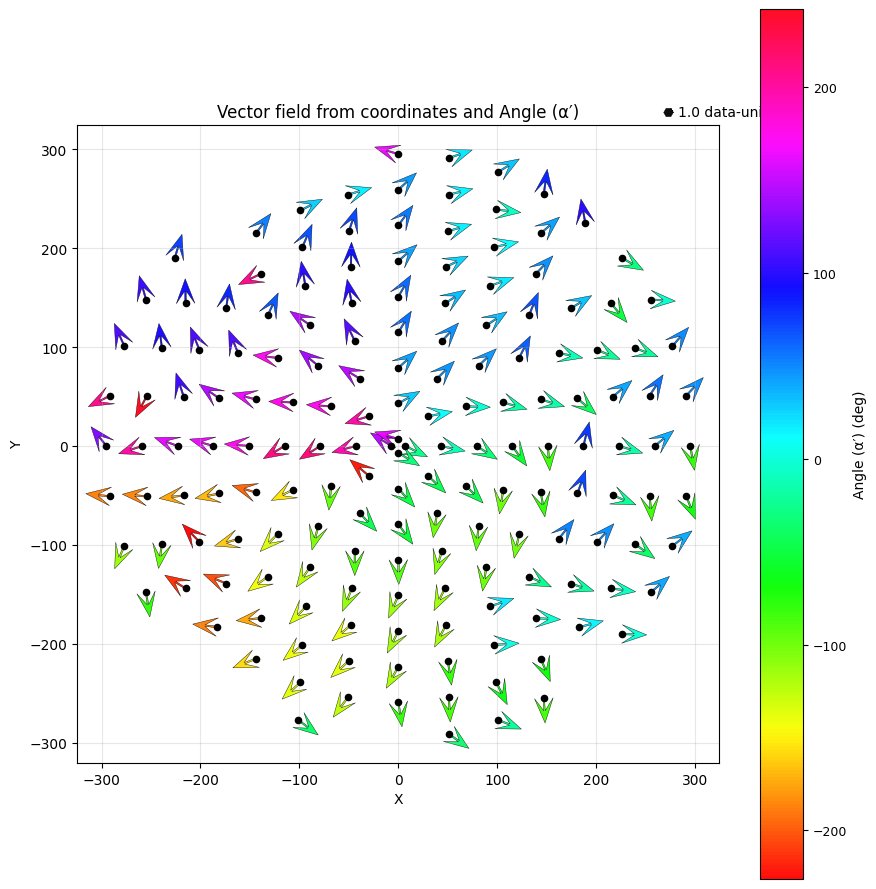

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# helper functions 
import ast

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)          # handles "(7.00, 0.00)" or "[7.00, 0.00]"
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]
# Extract angles and filter valid data
angles_deg = df['Angle (α′)'].values 

# df['Coordinate'] = df['Coordinate'].apply(lambda x: np.array(x))    
coordinates = df['Coordinate'].apply(parse_coord).tolist()
# Find global theta from the coordinates 

# For these angles and coordinates, plot a vector field
X = [coord[0] for coord in coordinates]
Y = [coord[1] for coord in coordinates]
r = np.sqrt(np.array(X)**2 + np.array(Y)**2)
theta = np.arctan2(
    np.array(Y),
    np.array(X)
)
phi = angles_deg + np.degrees(theta)
phi_rad = np.deg2rad(phi)
U_plot = np.cos(phi_rad)
V_plot = np.sin(phi_rad)
# Compute a reasonable scale factor for the quiver key
scale_factor = np.round(np.percentile(np.sqrt(U_plot**2 + V_plot**2), 75), 1)
if scale_factor == 0:
    scale_factor = 1.0
# Create the plot
plt.figure(figsize=(9, 9))
magnitude_scale = 25.0
U_plot_scaled = magnitude_scale * U_plot
V_plot_scaled = magnitude_scale * V_plot
q = plt.quiver(
    X, Y, U_plot_scaled, V_plot_scaled, phi,
    angles='xy', scale_units='xy', scale=1, cmap='hsv',
    width=0.015,
    headwidth=12,
    headlength=16,
    headaxislength=8,
    alpha=0.95, edgecolor='k', linewidth=0.3
)
plt.scatter(X, Y, c='k', s=20, zorder=3)
plt.gca().set_aspect('equal', 'box')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Vector field from coordinates and Angle (α′)')
cbar = plt.colorbar(q, label='Angle (α′) (deg)')
cbar.ax.tick_params(labelsize=9)
plt.quiverkey(q, X=0.92, Y=1.02, U=scale_factor,
              label=f'{scale_factor} data-units', labelpos='E',
              fontproperties={'size':10})
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('vector_field_plot.svg', dpi=300)
plt.show()

## 

<>:107: SyntaxWarning: invalid escape sequence '\p'
<>:113: SyntaxWarning: invalid escape sequence '\p'
<>:107: SyntaxWarning: invalid escape sequence '\p'
<>:113: SyntaxWarning: invalid escape sequence '\p'
/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_13349/1289691042.py:107: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(r_grid, np.degrees(psi_est_profile), color='red', linewidth=3, label='Learned $\psi(r)$')
/var/folders/kq/dktrln_x0tgf7tr54wrn711r0000gn/T/ipykernel_13349/1289691042.py:113: SyntaxWarning: invalid escape sequence '\p'
  plt.title("Learned Spiral Structure (Mod $\pi$)")


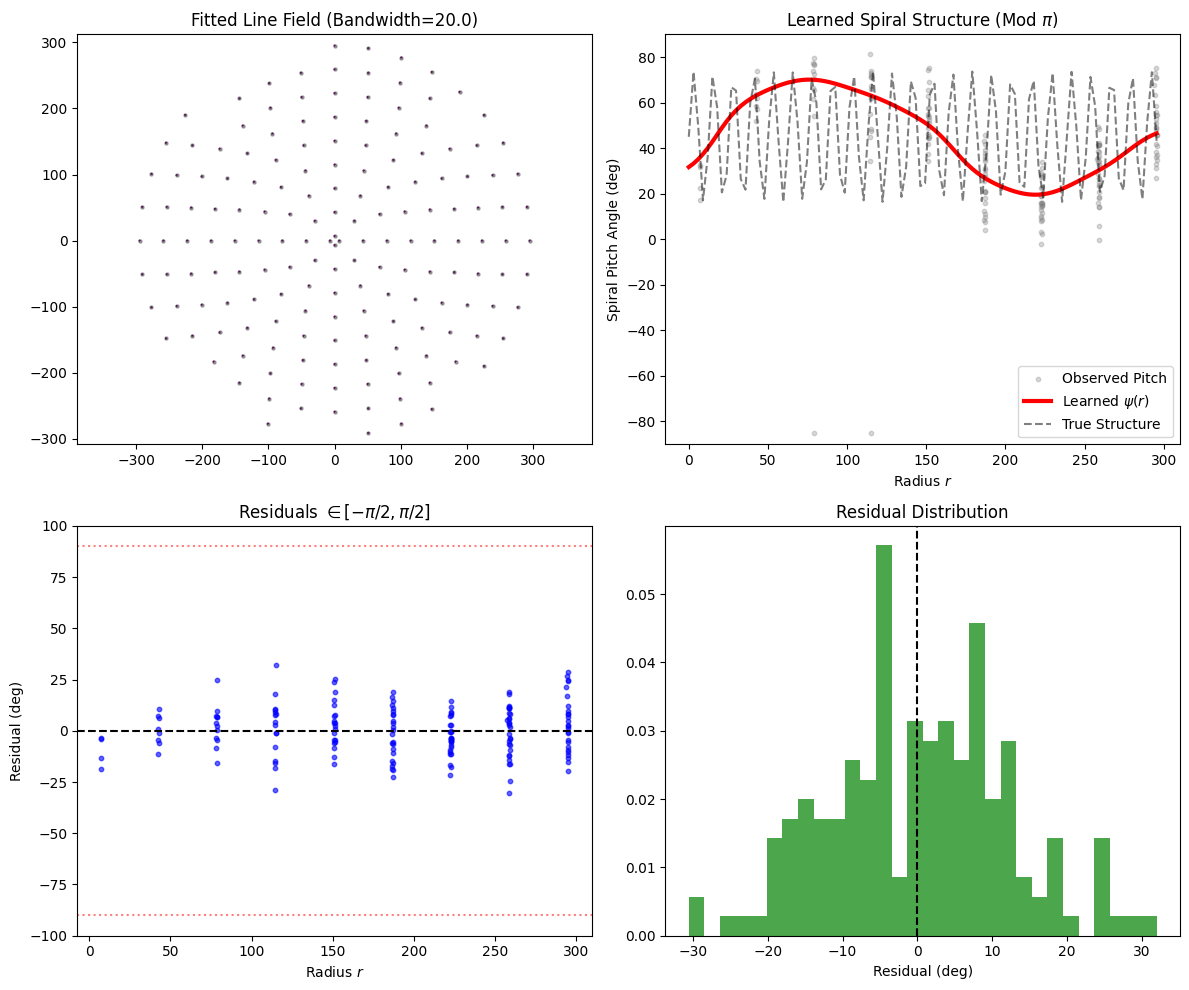

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Synthetic Line Field Data ---
# np.random.seed(42)
# n_points = 300
# X = np.random.uniform(-10, 10, n_points)
# Y = np.random.uniform(-10, 10, n_points)
X = np.array(X)
Y = np.array(Y)
n_points = len(X)
r = np.sqrt(X**2 + Y**2) + 1e-6
phi_spatial = np.arctan2(Y, X)

# Define True "Spiral Pitch" (Angle relative to radius)
# Example: 45 degrees constant (Log Spiral) -> psi = pi/4
# We will make it vary with r to show off the non-parametric capability
psi_true = np.pi/4 + 0.5 * np.sin(r/2)

# Global Angle of the line
theta_true = phi_spatial + psi_true

# Add Noise (Von Mises is theoretically better for angles, but Gaussian is fine for high SNR)
noise = np.random.normal(0, 0.2, n_points) 
theta_obs = theta_true + noise

# Note: We do NOT generate U/V vectors here because signs don't matter.
# We work purely with angles.

# --- 2. The "Double Angle" Kernel Smoothing ---

def gaussian_kernel(u):
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def smooth_line_field(target_r, sample_r, sample_theta, sample_phi_spatial, bandwidth):
    """
    Performs kernel regression on the relative angle (spiral pitch)
    using the double-angle representation.
    """
    # 1. Compute Relative Angle (Spiral Pitch)
    # This removes the rotational component, leaving just the spiral geometry
    psi_obs = sample_theta - sample_phi_spatial
    
    # 2. Map to 2*psi space (Doubling)
    # This maps [0, pi) to [0, 2pi), removing the ambiguity between direction and -direction
    cos_2psi = np.cos(2 * psi_obs)
    sin_2psi = np.sin(2 * psi_obs)
    
    # 3. Kernel Smoothing on components
    # Calculate weights
    u = (target_r[:, None] - sample_r[None, :]) / bandwidth
    weights = gaussian_kernel(u)
    sum_weights = np.sum(weights, axis=1)
    sum_weights[sum_weights < 1e-10] = 1.0 # Avoid div/0
    
    # Weighted averages
    avg_cos = np.sum(weights * cos_2psi[None, :], axis=1) / sum_weights
    avg_sin = np.sum(weights * sin_2psi[None, :], axis=1) / sum_weights
    
    # 4. Recover Angle
    # atan2 gives angle in (-pi, pi], divide by 2 gives (-pi/2, pi/2]
    psi_est = 0.5 * np.arctan2(avg_sin, avg_cos)
    
    return psi_est

# Define grid and bandwidth
r_grid = np.linspace(0, np.max(r), 100)
bandwidth = 20.0

# Fit the model
psi_est_profile = smooth_line_field(r_grid, r, theta_obs, phi_spatial, bandwidth)

# Predict on training data for residuals
psi_fitted = smooth_line_field(r, r, theta_obs, phi_spatial, bandwidth)
theta_fitted = phi_spatial + psi_fitted

# --- 3. Compute Line Field Residuals ---
# Error must be wrapped to [-pi/2, pi/2]
raw_error = theta_obs - theta_fitted
residuals = np.mod(raw_error + np.pi/2, np.pi) - np.pi/2

# Convert to degrees for easier reading
res_deg = np.degrees(residuals)

# --- 4. Visualization ---

plt.figure(figsize=(12, 10))

# Plot 1: The Vector Field (Headless)
plt.subplot(2, 2, 1)
# Create headless vectors for visualization
U_vis = np.cos(theta_fitted)
V_vis = np.sin(theta_fitted)
# We plot the field with NO heads to emphasize it's a line field
plt.quiver(X, Y, U_vis, V_vis, angles='xy', scale_units='xy', scale=0.5, 
           headwidth=0, headlength=0, headaxislength=0, # No arrows
           pivot='mid', color='purple', alpha=0.8, width=0.005)
plt.scatter(X, Y, s=5, c='k', alpha=0.3)
plt.title(f"Fitted Line Field (Bandwidth={bandwidth})")
plt.axis('equal')

# Plot 2: The Structure Function (Psi vs r)
plt.subplot(2, 2, 2)
# Wrap observed psi for plotting consistency
psi_obs_wrapped = np.arctan(np.tan(theta_obs - phi_spatial)) 
plt.scatter(r, np.degrees(psi_obs_wrapped), alpha=0.3, color='gray', s=10, label='Observed Pitch')
plt.plot(r_grid, np.degrees(psi_est_profile), color='red', linewidth=3, label='Learned $\psi(r)$')
plt.plot(r_grid, np.degrees(np.pi/4 + 0.5 * np.sin(r_grid/2)), 'k--', alpha=0.5, label='True Structure')
plt.xlabel('Radius $r$')
plt.ylabel('Spiral Pitch Angle (deg)')
plt.ylim(-90, 90)
plt.legend()
plt.title("Learned Spiral Structure (Mod $\pi$)")

# Plot 3: Residuals Scatter
plt.subplot(2, 2, 3)
plt.scatter(r, res_deg, alpha=0.6, color='blue', s=10)
plt.axhline(0, color='k', linestyle='--')
plt.axhline(90, color='r', linestyle=':', alpha=0.5)
plt.axhline(-90, color='r', linestyle=':', alpha=0.5)
plt.xlabel('Radius $r$')
plt.ylabel('Residual (deg)')
plt.title(r'Residuals $\in [-\pi/2, \pi/2]$')
plt.ylim(-100, 100)

# Plot 4: Residual Histogram
plt.subplot(2, 2, 4)
plt.hist(res_deg, bins=30, color='green', alpha=0.7, density=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Residual (deg)')
plt.title('Residual Distribution')

plt.tight_layout()
plt.show()

Using Bandwidth h = 29.48


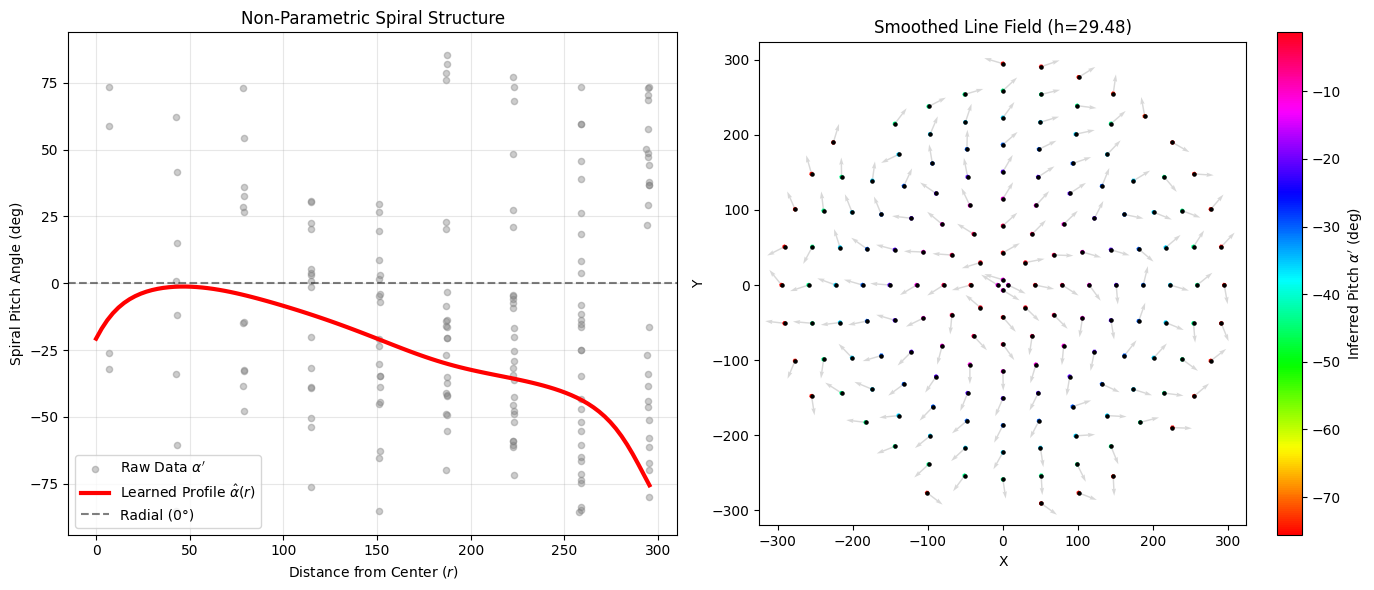

Using Bandwidth h = 29.48


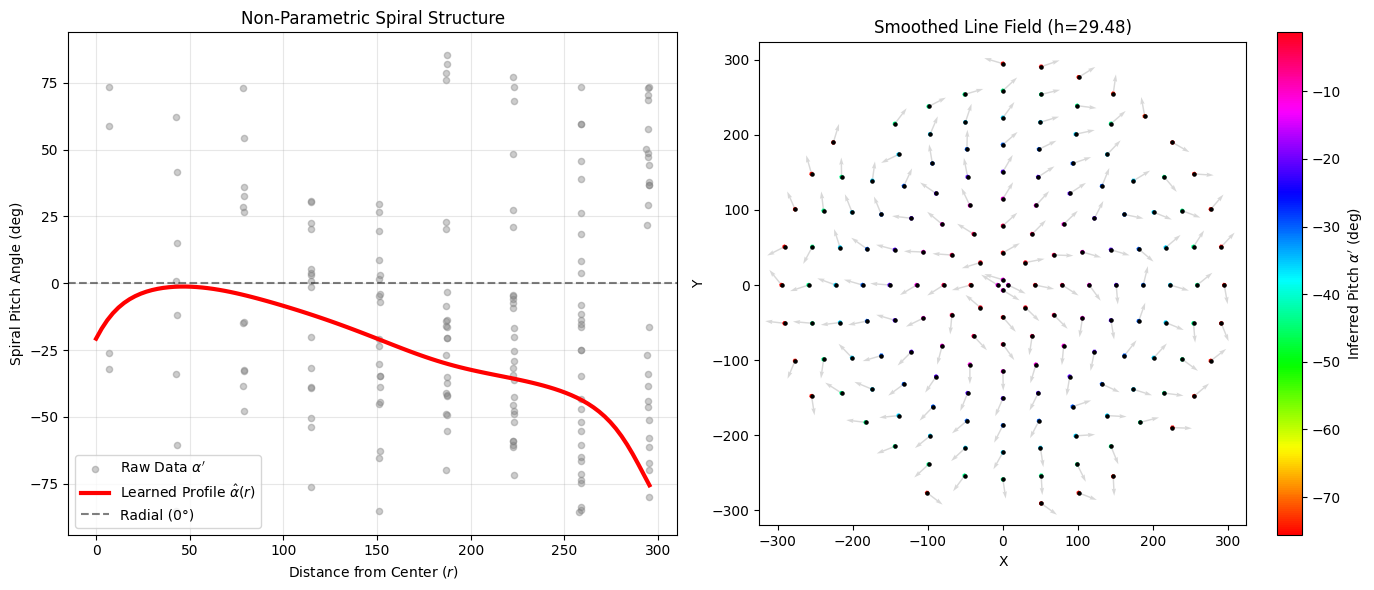

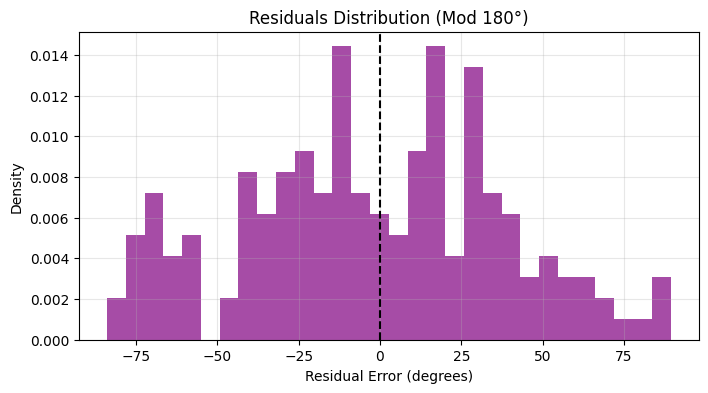

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ast

# --- 1. Data Preparation (Using your parsing logic) ---
# We assume 'df' is your loaded dataframe
# If you need dummy data to run this immediately, uncomment the block below:
# ---------------------------------------------------------
# N = 300
# df = pd.DataFrame()
# # Synthetic data: r roughly 0 to 10
# X_syn = np.random.uniform(-10, 10, N)
# Y_syn = np.random.uniform(-10, 10, N)
# r_syn = np.sqrt(X_syn**2 + Y_syn**2)
# # True structure: pitch decays from 45 deg to 0 deg
# alpha_true = 45 * np.exp(-r_syn/5) + np.random.normal(0, 10, N)
# df['Angle (α′)'] = alpha_true
# df['Coordinate'] = [f"({x:.2f}, {y:.2f})" for x, y in zip(X_syn, Y_syn)]
# ---------------------------------------------------------

def parse_coord(s):
    if isinstance(s, (list, tuple, np.ndarray)):
        return list(s)
    if not isinstance(s, str):
        return [np.nan, np.nan]
    s = s.strip()
    try:
        val = ast.literal_eval(s)
        return list(val)
    except Exception:
        parts = [p.strip() for p in s.strip("()[]").split(",")]
        try:
            return [float(parts[0]), float(parts[1])]
        except Exception:
            return [np.nan, np.nan]

coordinates = df['Coordinate'].apply(parse_coord).tolist()
X = np.array([coord[0] for coord in coordinates])
Y = np.array([coord[1] for coord in coordinates])

# Compute Spatial Parameters
r_obs = np.sqrt(X**2 + Y**2)
theta_spatial = np.arctan2(Y, X) # Radians

# Observed Relative Angle (Pitch) in Radians
# We use this directly for smoothing
alpha_obs_deg = df['Angle (α′)'].values
alpha_obs_rad = np.radians(alpha_obs_deg)

# --- 2. The Line-Field Kernel Smoother ---

def gaussian_kernel(u):
    return (1.0 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def smooth_spiral_pitch(target_r, sample_r, sample_alpha_rad, bandwidth):
    """
    Smooths the relative spiral angle alpha using double-angle metric
    to respect line field symmetry (alpha == alpha + pi).
    """
    # Map to double angle space (2*alpha)
    # This maps 90 deg and -90 deg to the same vector in the embedding space
    cos_2alpha = np.cos(2 * sample_alpha_rad)
    sin_2alpha = np.sin(2 * sample_alpha_rad)
    
    # Kernel weights
    u = (target_r[:, None] - sample_r[None, :]) / bandwidth
    weights = gaussian_kernel(u)
    
    sum_weights = np.sum(weights, axis=1)
    # Handle data gaps
    sum_weights[sum_weights < 1e-10] = 1.0 
    
    # Weighted average of components
    avg_cos = np.sum(weights * cos_2alpha[None, :], axis=1) / sum_weights
    avg_sin = np.sum(weights * sin_2alpha[None, :], axis=1) / sum_weights
    
    # Recover angle: atan2 gives (-pi, pi], divide by 2 gives (-pi/2, pi/2]
    alpha_est = 0.5 * np.arctan2(avg_sin, avg_cos)
    
    return alpha_est

# --- 3. Execution ---

# Setup Grid
r_grid = np.linspace(0, np.max(r_obs), 100)

# Tunable Hyperparameter (Bandwidth)
# Since coordinates look like they range 0-10 or 0-100, pick reasonable scale
# If X is ~2000 units, b should be ~200. If X is ~10 units, b ~ 1.0.
bandwidth = np.percentile(r_obs, 90) / 10.0 
print(f"Using Bandwidth h = {bandwidth:.2f}")

# 1. Learn the Structure Function alpha(r)
alpha_fitted_rad_grid = smooth_spiral_pitch(r_grid, r_obs, alpha_obs_rad, bandwidth)

# 2. Predict on original points (for residuals/plotting)
alpha_fitted_rad = smooth_spiral_pitch(r_obs, r_obs, alpha_obs_rad, bandwidth)

# 3. Reconstruct Global Field vectors
# phi_fitted = theta_spatial + alpha_fitted(r)
phi_fitted_rad = theta_spatial + alpha_fitted_rad
U_fit = np.cos(phi_fitted_rad)
V_fit = np.sin(phi_fitted_rad)

# --- 4. Visualization ---

plt.figure(figsize=(14, 6))

# Subplot 1: The Structure Function (The Physics)
# This shows exactly how the spiral pitch changes with distance
plt.subplot(1, 2, 1)
# Wrap observed alphas to [-90, 90] for consistent plotting
alpha_obs_wrapped = np.degrees(np.arctan(np.tan(alpha_obs_rad)))
plt.scatter(r_obs, alpha_obs_wrapped, c='gray', alpha=0.4, s=20, label='Raw Data $\\alpha\'$')
plt.plot(r_grid, np.degrees(alpha_fitted_rad_grid), color='red', linewidth=3, label='Learned Profile $\\hat{\\alpha}(r)$')
plt.axhline(0, color='k', linestyle='--', alpha=0.5, label='Radial (0°)')
plt.xlabel('Distance from Center ($r$)')
plt.ylabel('Spiral Pitch Angle (deg)')
plt.title('Non-Parametric Spiral Structure')
plt.legend()
plt.grid(alpha=0.3)

# Subplot 2: The Vector Field Comparison
ax2 = plt.subplot(1, 2, 2)

# Plot Original Noisy Field (Gray/Thin)
phi_obs_rad = np.radians(df['Angle (α′)'].values) + theta_spatial
U_raw = np.cos(phi_obs_rad)
V_raw = np.sin(phi_obs_rad)
plt.quiver(X, Y, U_raw, V_raw, color='gray', alpha=0.3, 
           scale=25, width=0.003, headwidth=3)

# Plot Fitted Smooth Field (Colored/Thick)
# Using headwidth=0 to denote Line Field (Director field)
q = plt.quiver(X, Y, U_fit, V_fit, np.degrees(alpha_fitted_rad),
           angles='xy', scale_units='xy', scale=1, cmap='hsv',
           width=0.01, headwidth=0, pivot='mid') # Headless vectors

plt.colorbar(q, label='Inferred Pitch $\\alpha\'$ (deg)')
plt.scatter(X, Y, c='k', s=5, zorder=3)
ax2.set_aspect('equal')
plt.xlabel('X')
plt.ylabel('Y')
plt.title(f'Smoothed Line Field (h={bandwidth:.2f})')

plt.tight_layout()
plt.show()

# --- 5. Residual Analysis (Mod Pi) ---
# Calculate error in [-pi/2, pi/2]
error_rad = alpha_obs_rad - alpha_fitted_rad
residuals = np.mod(error_rad + np.pi/2, np.pi) - np.pi/2
residuals_deg = np.degrees(residuals)

plt.figure(figsize=(8, 4))
plt.hist(residuals_deg, bins=30, color='purple', alpha=0.7, density=True)
plt.axvline(0, color='k', linestyle='--')
plt.xlabel('Residual Error (degrees)')
plt.ylabel('Density')
plt.title('Residuals Distribution (Mod 180°)')
plt.grid(alpha=0.3)
plt.show()

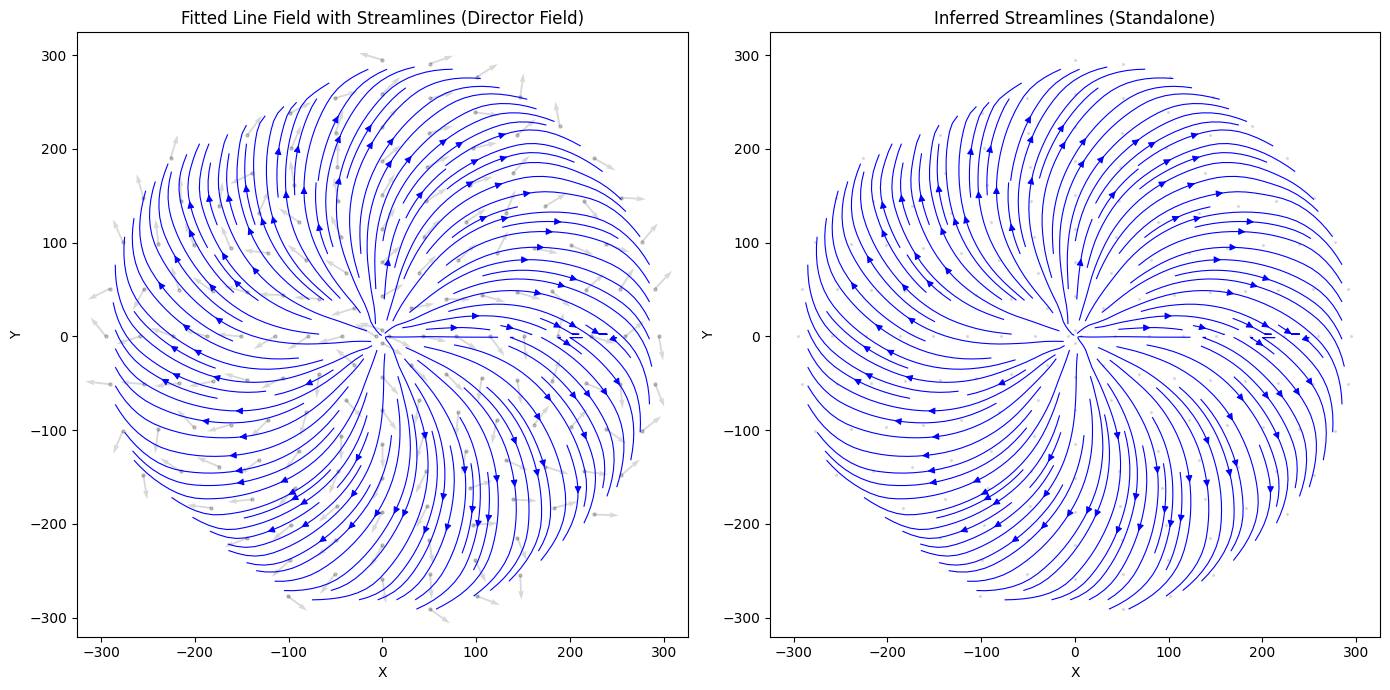

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# --- 1. Load Your Data ---
# We assume these variables exist from your previous Kernel Regression step:
# X, Y: The spatial coordinates (1D arrays)
# U_fit, V_fit: The fitted vector components (1D arrays)
# If you want to plot the RAW noisy data instead, use U_raw, V_raw.

# Filter out any NaNs just in case
valid_mask = ~(np.isnan(X) | np.isnan(Y) | np.isnan(U_fit) | np.isnan(V_fit))
x_clean = X[valid_mask]
y_clean = Y[valid_mask]
u_clean = U_fit[valid_mask]
v_clean = V_fit[valid_mask]

# --- 2. Interpolate to Grid ---
# Create a dense regular grid for the streamplot
grid_points = 200  # Higher = smoother resolution
xi = np.linspace(min(x_clean), max(x_clean), grid_points)
yi = np.linspace(min(y_clean), max(y_clean), grid_points)
Xi, Yi = np.meshgrid(xi, yi)

# Interpolate U and V onto this grid
# 'cubic' gives smoother curves than 'linear', but 'linear' is safer near boundaries.
Ui = griddata((x_clean, y_clean), u_clean, (Xi, Yi), method='linear')
Vi = griddata((x_clean, y_clean), v_clean, (Xi, Yi), method='linear')

# --- 3. Line Field Continuity Correction (Crucial!) ---
# Since this is a line field, U is equivalent to -U. 
# We must ensure the vector field is locally continuous for streamplot to work.
rows, cols = Ui.shape
for i in range(rows):
    for j in range(1, cols):
        # Skip NaNs (which happen outside the convex hull of data)
        if np.isnan(Ui[i,j]) or np.isnan(Ui[i,j-1]):
            continue
            
        # Check dot product with neighbor
        dot = Ui[i,j]*Ui[i,j-1] + Vi[i,j]*Vi[i,j-1]
        
        # If vectors point in opposite directions, flip the current one
        # to maintain the "flow" visually
        if dot < 0:
            Ui[i,j] *= -1
            Vi[i,j] *= -1

# Fill NaNs (outside data area) with 0 to prevent streamplot crash
mask_nan = np.isnan(Ui) | np.isnan(Vi)
Ui[mask_nan] = 0
Vi[mask_nan] = 0

# --- 4. Visualization ---
plt.figure(figsize=(14, 7))

# Plot A: The Fitted Line Field (Headless Quiver) with Streamlines Overlaid
ax1 = plt.subplot(1, 2, 1)
plt.title("Fitted Line Field with Streamlines (Director Field)")
plt.quiver(X, Y, U_raw, V_raw, color='gray', alpha=0.3, 
           scale=25, width=0.003, headwidth=3)

# q = plt.quiver(X, Y, U_fit, V_fit, np.degrees(alpha_fitted_rad),
#            angles='xy', scale_units='xy', scale=1, cmap='hsv',
#            width=0.01, headwidth=0, pivot='mid') # Headless vectors
# plt.colorbar(q, label='Inferred Pitch $\\alpha\'$ (deg)')
plt.scatter(x_clean, y_clean, s=5, c='k', alpha=0.2)

# Overlay streamlines with arrowsize=1.0
strm1 = plt.streamplot(Xi, Yi, Ui, Vi, 
                       density=2.0,       # Higher = more dense lines
                       color='blue', 
                       linewidth=0.8, 
                       arrowsize=1.0)       # Directional arrows on top of line field
plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')

# Plot B: The Streamlines Only
ax2 = plt.subplot(1, 2, 2)
plt.title("Inferred Streamlines (Standalone)")

# Plot the streamlines
strm2 = plt.streamplot(Xi, Yi, Ui, Vi, 
                       density=2.0,       # Higher = more dense lines
                       color='blue', 
                       linewidth=0.8, 
                       arrowsize=1.0)       # Set to 0 for pure structure

# Overlay original points for context
plt.scatter(x_clean, y_clean, color='black', s=2, alpha=0.1)

plt.axis('equal')
plt.xlabel('X')
plt.ylabel('Y')

plt.tight_layout()
plt.savefig('streamlines_fitted.svg', dpi=300)
plt.show()

In [ ]:
## Verify Bayes factor calculation